# Loan Approval Prediction using Logistic Regression

## Dataset
**Source:** [Loan Prediction Dataset — Kaggle](https://www.kaggle.com/datasets/ninzaami/loan-predication/data)

**Context:**  
This dataset contains information about loan applicants collected by a financial institution. The goal is to automate the loan eligibility process based on customer details provided while filling out an online application form.

**Attributes:**
| Feature | Description |
|---|---|
| Loan_ID | Unique loan identifier |
| Gender | Applicant gender (Male/Female) |
| Married | Marital status (Yes/No) |
| Dependents | Number of dependents (0, 1, 2, 3+) |
| Education | Education level (Graduate/Not Graduate) |
| Self_Employed | Self-employment status (Yes/No) |
| ApplicantIncome | Applicant monthly income |
| CoapplicantIncome | Co-applicant monthly income |
| LoanAmount | Loan amount requested (in thousands) |
| Loan_Amount_Term | Term of the loan (in months) |
| Credit_History | Credit history meets guidelines (1 = Yes, 0 = No) |
| Property_Area | Area of property (Urban/Semi-Urban/Rural) |
| Loan_Status | Target variable — loan approved (Y=1) or rejected (N=0) |

**Size:** 614 records, 13 columns

---

## Algorithm: Logistic Regression

### Background
Logistic Regression is a supervised machine learning algorithm used for **binary classification** tasks. Despite its name, it is a classification algorithm, not a regression one. It models the probability that an input belongs to a particular class using the **logistic (sigmoid) function**:

$$P(y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + ... + \beta_n X_n)}}$$

The output is a probability between 0 and 1. A threshold (typically 0.5) is used to make the final class prediction.

### Justification
Logistic Regression is an appropriate choice for this problem because:
1. **Binary target variable** — Loan_Status is either Approved (1) or Rejected (0), which is exactly what logistic regression is designed for.
2. **Interpretability** — The model coefficients directly show the influence of each feature on loan approval, which is valuable in financial contexts.
3. **Efficiency** — The dataset is small (614 rows), making a simple model like Logistic Regression well-suited without the risk of overfitting.
4. **Baseline model** — It serves as a strong, interpretable baseline before trying more complex models.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# Set a consistent style for all plots
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

## 2. Load Dataset

In [2]:
# Load the loan dataset from Google Drive
df = pd.read_csv("drive/MyDrive/ml-assignment/loan-dataset.csv")

# Display the first few rows to understand the structure
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 3. Exploratory Data Analysis

In [3]:
# Check data types and non-null counts for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
# Count missing values per column to plan our imputation strategy
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [5]:
# Check class distribution of the target variable
# This reveals whether there is a class imbalance issue
print("Target variable distribution:")
print(df['Loan_Status'].value_counts())
print(f"\nApproval rate: {df['Loan_Status'].value_counts(normalize=True)['Y']*100:.1f}%")

Target variable distribution:
Loan_Status
Y    422
N    192
Name: count, dtype: int64

Approval rate: 68.7%


## 4. Data Preprocessing

In [6]:
# --- Handling Missing Values ---

# For categorical columns, fill missing values with the mode (most frequent value)
# This is appropriate since these are nominal/ordinal categories
df['Gender']        = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married']       = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents']    = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

# For numerical columns, fill missing values with the median
# Median is preferred over mean here because LoanAmount and
# Loan_Amount_Term may have outliers that would skew the mean
df['LoanAmount']       = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

# Credit_History is binary (0 or 1), so median makes sense here too
df['Credit_History']   = df['Credit_History'].fillna(df['Credit_History'].median())

# Verify no missing values remain
print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [7]:
# --- Fix the '3+' value in Dependents ---
# The '3+' string cannot be encoded numerically, so replace it with '3'
df['Dependents'] = df['Dependents'].replace('3+', '3')

In [8]:
# --- Drop Loan_ID ---
# Loan_ID is just a unique identifier and carries no predictive information
df.drop('Loan_ID', axis=1, inplace=True)

In [9]:
# --- Label Encoding ---
# Convert all categorical (object) columns to numeric values
# Logistic Regression requires all inputs to be numeric
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
    print(f"Encoded '{col}'")

print("\nDataset after encoding:")
df.head()

Encoded 'Gender'
Encoded 'Married'
Encoded 'Dependents'
Encoded 'Education'
Encoded 'Self_Employed'
Encoded 'Property_Area'
Encoded 'Loan_Status'

Dataset after encoding:


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


## 5. Feature & Target Split

In [10]:
# Separate input features (X) from the target variable (y)
X = df.drop('Loan_Status', axis=1)   # All columns except the target
y = df['Loan_Status']                 # Target: 1 = Approved, 0 = Rejected

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features shape: (614, 11)
Target shape:   (614,)

Feature columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


## 6. Train-Test Split

In [11]:
# Split dataset: 80% training, 20% testing
# random_state=42 ensures reproducible results across runs
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 491
Testing samples:  123


## 7. Feature Scaling

In [12]:
# Standardise features to have zero mean and unit variance
# This is important for Logistic Regression because features like
# ApplicantIncome (in thousands) and Credit_History (0 or 1) are on
# very different scales — scaling prevents larger-valued features from
# dominating the model

scaler = StandardScaler()

# IMPORTANT: fit only on training data to avoid data leakage,
# then apply the same transformation to the test set
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

## 8. Train Logistic Regression Model

In [13]:
# Initialise and train the Logistic Regression model
# max_iter=2000 is set higher than default (100) to ensure the
# optimiser converges fully on this dataset
# class_weight='balanced' adjusts for the class imbalance between
# approved and rejected loans automatically
model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

print("Model training complete.")
print(f"Model parameters: {model.get_params()}")

Model training complete.
Model parameters: {'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 2000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


## 9. Model Evaluation & Results

In [14]:
# Generate predictions on the unseen test set
y_pred = model.predict(X_test)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Detailed classification report showing precision, recall, and F1-score
# per class — far more informative than accuracy alone for imbalanced datasets
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected (0)', 'Approved (1)']))

Accuracy: 0.7724 (77.24%)

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.80      0.47      0.59        43
Approved (1)       0.77      0.94      0.84        80

    accuracy                           0.77       123
   macro avg       0.78      0.70      0.72       123
weighted avg       0.78      0.77      0.75       123



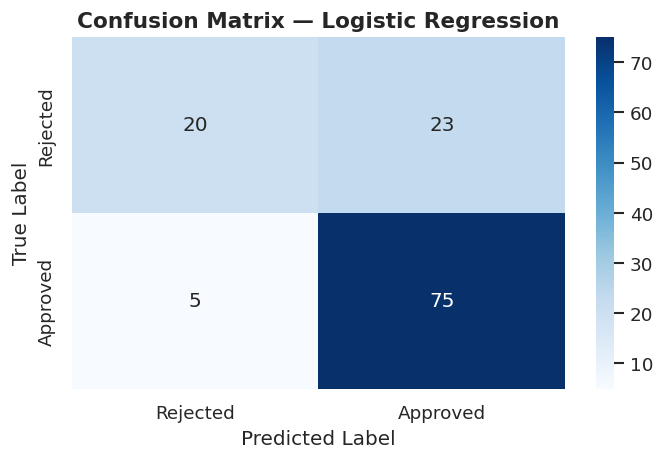

In [15]:
# --- Confusion Matrix Heatmap ---
# Rows = actual class, Columns = predicted class
# Top-left: True Negatives (correctly predicted Rejected)
# Top-right: False Positives (predicted Approved but actually Rejected)
# Bottom-left: False Negatives (predicted Rejected but actually Approved)
# Bottom-right: True Positives (correctly predicted Approved)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Rejected', 'Approved'],
    yticklabels=['Rejected', 'Approved']
)
plt.title('Confusion Matrix — Logistic Regression', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

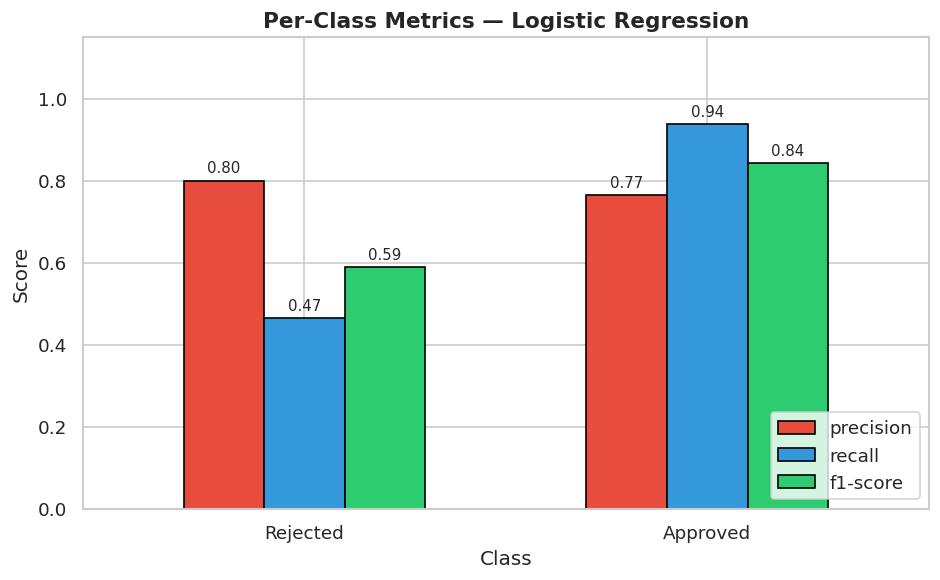

In [16]:
# --- Per-Class Metrics Bar Chart ---
# Visualises precision, recall, and F1-score for each class side-by-side
# to clearly show where the model struggles (Rejected class)

report = classification_report(
    y_test, y_pred,
    target_names=['Rejected', 'Approved'],
    output_dict=True
)

metrics_df = pd.DataFrame(report).T.loc[['Rejected', 'Approved'], ['precision', 'recall', 'f1-score']]

metrics_df.plot(
    kind='bar', figsize=(8, 5),
    color=['#e74c3c', '#3498db', '#2ecc71'],
    edgecolor='black', width=0.6
)
plt.title('Per-Class Metrics — Logistic Regression', fontsize=13, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Score')
plt.ylim(0, 1.15)
plt.xticks(rotation=0)
plt.legend(loc='lower right')

# Annotate each bar with its value
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

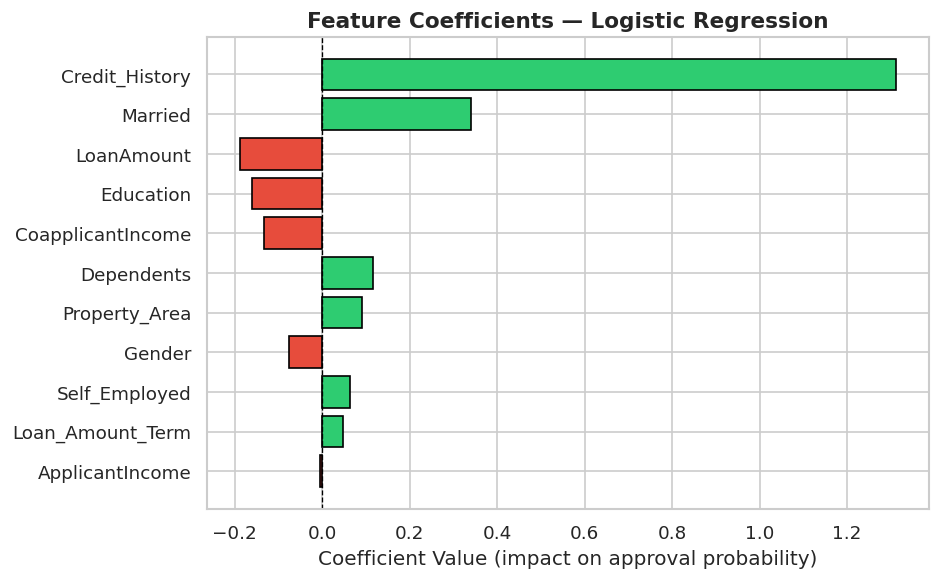

Green bars = push toward Approved | Red bars = push toward Rejected


In [17]:
# --- Feature Importance (Logistic Regression Coefficients) ---
# The magnitude of each coefficient shows how strongly a feature
# influences the prediction.
# Positive coefficient -> pushes toward Approved
# Negative coefficient -> pushes toward Rejected

feature_names  = X.columns.tolist()
coefficients   = model.coef_[0]
sorted_idx     = np.argsort(np.abs(coefficients))[::-1]

colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefficients[sorted_idx]]

plt.figure(figsize=(8, 5))
plt.barh(
    np.array(feature_names)[sorted_idx],
    coefficients[sorted_idx],
    color=colors, edgecolor='black'
)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Coefficients — Logistic Regression', fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value (impact on approval probability)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Green bars = push toward Approved | Red bars = push toward Rejected")

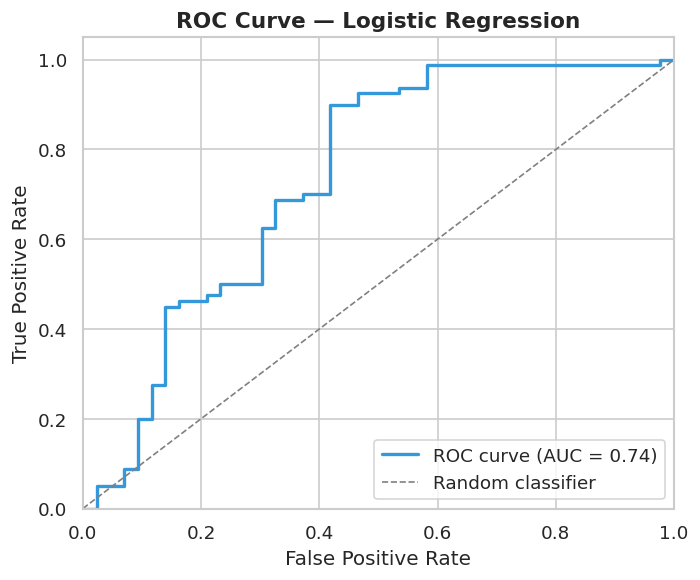

In [18]:
# --- ROC Curve ---
# The ROC curve shows the trade-off between True Positive Rate (sensitivity)
# and False Positive Rate at various classification thresholds.
# AUC (Area Under the Curve) closer to 1.0 = better model.

y_prob        = model.predict_proba(X_test)[:, 1]  # probability of class 1 (Approved)
fpr, tpr, _   = roc_curve(y_test, y_prob)
roc_auc       = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#3498db', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 10. Critical Analysis & Discussion

## Model Performance Summary

| Metric | Rejected (0) | Approved (1) |
|---|---|---|
| Precision | 0.80 | 0.77 |
| Recall | 0.47 | 0.94 |
| F1-Score | 0.59 | 0.84 |
| Overall Accuracy | — | 77.24% |
| AUC (ROC) | — | 0.74 |

## Confusion Matrix Breakdown

| | Predicted Rejected | Predicted Approved |
|---|---|---|
| **Actual Rejected** | 20 (True Negative) | 23 (False Positive) |
| **Actual Approved** | 5 (False Negative) | 75 (True Positive) |

## Interpretation

The model achieves **77.24% overall accuracy**, but this figure alone does not tell the full story. The model performs significantly better on the **Approved class** than on the **Rejected class**:

- It correctly identifies **94%** of approved loans (high recall for class 1)
- But only correctly identifies **47%** of rejected loans (low recall for class 0)

This means the model **misses more than half of actual loan rejections** — specifically, 23 out of 43 rejected loans were incorrectly predicted as approved. In a real banking system, a false approval (granting a loan to a borrower who should be rejected) carries significant financial risk.

The root cause is **class imbalance** — the dataset contains roughly 65% approvals vs 35% rejections, so the model naturally learns to favour predicting the majority class. Although `class_weight='balanced'` was applied to partially correct this, the imbalance effect is still visible in the results.

The **ROC AUC score of 0.74** indicates moderate discriminative ability. A score of 1.0 would represent a perfect classifier, while 0.5 represents random guessing. The 0.74 score suggests the model has reasonable but limited ability to distinguish between approved and rejected applicants, and there is room for improvement.

## Key Feature Insights

From the feature coefficient plot, **Credit_History** is by far the most influential feature (coefficient ≈ 1.3), strongly pushing predictions toward approval when satisfied. **Married** is the second most positive feature. Conversely, **LoanAmount**, **Education**, and **CoapplicantIncome** slightly push toward rejection. Notably, **ApplicantIncome** has near-zero influence, which is counterintuitive and suggests income alone may not be a strong predictor in this dataset without further feature engineering.

## How Accuracy Could Be Improved

1. **Address class imbalance further** — While `class_weight='balanced'` was applied, a stronger approach would be to use **SMOTE** (Synthetic Minority Oversampling Technique) to generate synthetic samples for the minority (Rejected) class before training, giving the model more examples of rejections to learn from.

2. **Feature engineering** — Create a combined `Total_Income` feature (ApplicantIncome + CoapplicantIncome) and apply log transformation to skewed features like `LoanAmount` to reduce the effect of outliers. The near-zero coefficient of `ApplicantIncome` suggests the raw income value is not informative, but a ratio like `LoanAmount / TotalIncome` could be much more predictive.

3. **Hyperparameter tuning** — Use `GridSearchCV` to find the optimal regularisation strength parameter `C`. Stronger regularisation (`C < 1`) can prevent the model from over-relying on dominant features like `Credit_History`, potentially improving generalisation.

4. **Threshold adjustment** — Instead of using the default 0.5 decision threshold, lowering it (e.g. to 0.3) would make the model more sensitive to predicting rejections, improving recall for class 0 at the cost of some precision.

## Limitations of Logistic Regression

- Assumes a **linear relationship** between the features and the log-odds of approval, which may not hold in reality (e.g. the effect of income on approval is likely non-linear)
- Cannot automatically capture **interaction effects** between features — for example, the combined effect of low income and poor credit history may be far worse than either factor alone, but Logistic Regression treats them independently
- Sensitive to **outliers** in numerical features like `ApplicantIncome`, which can distort the learned coefficients
- The near-zero influence of `ApplicantIncome` despite its intuitive importance suggests the model may not be extracting the full signal from all features

## Future Work

- Compare Logistic Regression against non-linear models (Decision Tree, Random Forest, SVM) to determine whether the linear decision boundary is a performance bottleneck — the AUC of 0.74 suggests a more expressive model may improve results
- Investigate **model fairness** — the feature coefficient chart shows `Gender` has a negative coefficient (pushes toward rejection), which warrants examination of whether the model behaves equitably across gender groups
- Explore **threshold optimisation** using precision-recall curves to find the decision threshold that best balances the cost of false approvals vs false rejections based on a specific institution's risk policy
- Explore deployment as a **probability-based decision support tool** where loan officers receive an approval probability score and can apply their own judgment above a configurable threshold